In [17]:
import numpy as np
import pandas as pd
import yfinance as yf

# =============================================
# テーブルの順番通りに定義（順序が重要）
# =============================================
# (ティッカー, 資産クラス名, 対応指数)
ASSET_ORDER = [
    ("1306.T", "日本株式",    "TOPIX"),
    ("VEA",    "先進国株式",  "MSCI KOKUSAI 近似"),
    ("VT",     "全世界株式",  "MSCI ACWI"),
    ("VTI",    "米国株式",    "S&P500 近似"),
    ("EEM",    "新興国株式",  "MSCI エマージング"),
    ("1482.T", "国内債券",    "NOMURA-BPI 近似"),   # iシェアーズ 国内債券
    ("BNDX",   "先進国債券",  "FTSE 世界国債"),
    ("1343.T", "国内REIT",   "東証REIT指数"),
    ("RWX",    "先進国REIT", "S&P 先進国REIT"),
    ("GLD",    "金",          "LBMA 金価格"),
]

tickers  = [a[0] for a in ASSET_ORDER]
labels   = [a[1] for a in ASSET_ORDER]
indices  = [a[2] for a in ASSET_ORDER]

ticker_to_label = {a[0]: a[1] for a in ASSET_ORDER}
ticker_to_index = {a[0]: a[2] for a in ASSET_ORDER}

# =============================================
# 1. データ取得
# =============================================
print("=== 20年分データ取得 ===")
raw = yf.download(tickers, start="2005-01-01", end="2025-12-31",
                  auto_adjust=True)["Close"]
raw = raw.ffill().bfill()

# ASSET_ORDER の順番を保ったまま取得できた銘柄のみ残す
available = [t for t in tickers if t in raw.columns and raw[t].notna().sum() > 252]
raw = raw[available]   # 列順が ASSET_ORDER 通りになる

print(f"取得成功 : {available}")
print(f"期間     : {raw.index[0].date()} 〜 {raw.index[-1].date()}")
print(f"営業日数 : {len(raw):,} 日\n")

# =============================================
# 2. numpy 配列（順序保証済み）
# =============================================
prices        = raw.to_numpy(dtype=np.float64)
daily_returns = np.diff(prices, axis=0) / prices[:-1]
dates         = raw.index.to_numpy()

available_labels  = [ticker_to_label[t] for t in available]
available_indices = [ticker_to_index[t] for t in available]

print("numpy 配列 shape:")
print(f"  prices        : {prices.shape}")
print(f"  daily_returns : {daily_returns.shape}")
print(f"  dates         : {dates.shape}\n")

# =============================================
# 3. 年別×銘柄別 集計
# =============================================
TRADING_DAYS = 252

ret_df = pd.DataFrame(
    daily_returns,
    index  = pd.DatetimeIndex(dates[1:]),
    columns= available,
)

grouped = ret_df.groupby(ret_df.index.year)

annual_return = (grouped.mean() * TRADING_DAYS * 100).round(2)
annual_risk   = (grouped.std()  * np.sqrt(TRADING_DAYS) * 100).round(2)
annual_sharpe = (grouped.mean() / grouped.std()).round(3)

# 列名を資産クラス名に（ASSET_ORDER の順番が維持される）
annual_return.columns = available_labels
annual_risk.columns   = available_labels
annual_sharpe.columns = available_labels

# =============================================
# 4. 出力
# =============================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("=" * 90)
print("【年率リターン(%)  ―  列の順: テーブル定義順】")
print("=" * 90)
print(annual_return.to_string())

print("\n" + "=" * 90)
print("【年率リスク(%)】")
print("=" * 90)
print(annual_risk.to_string())

print("\n" + "=" * 90)
print("【シャープ・レシオ】")
print("=" * 90)
print(annual_sharpe.to_string())

# =============================================
# 5. 全期間平均サマリー（元テーブルと同じ順番で）
# =============================================
print("\n" + "=" * 90)
print("【全期間平均（実績値）― 元テーブルと同じ順番】")
print("=" * 90)

summary = pd.DataFrame({
    "ティッカー":      available,
    "対応指数":        available_indices,
    "年率リターン(%)": annual_return.mean().values,
    "年率リスク(%)":   annual_risk.mean().values,
    "シャープ(平均)":  annual_sharpe.mean().values,
}, index=available_labels).round(2)

print(summary.to_string())

# =============================================
# 6. 列の順番確認
# =============================================
print("\n--- 列の順番確認 ---")
for i, (t, label) in enumerate(zip(available, available_labels)):
    print(f"  列{i:2d}: {t:8s} → {label}")

[                       0%                       ]

=== 20年分データ取得 ===


[*********************100%***********************]  10 of 10 completed

取得成功 : ['1306.T', 'VEA', 'VT', 'VTI', 'EEM', '1482.T', 'BNDX', '1343.T', 'RWX', 'GLD']
期間     : 2005-01-03 〜 2025-12-30
営業日数 : 5,434 日

numpy 配列 shape:
  prices        : (5434, 10)
  daily_returns : (5433, 10)
  dates         : (5434,)

【年率リターン(%)  ―  列の順: テーブル定義順】
       日本株式  先進国株式  全世界株式   米国株式  新興国株式   国内債券  先進国債券  国内REIT  先進国REIT      金
2005   0.00   0.00   0.00   7.41  31.26   0.00   0.00    0.00     0.00  19.01
2006   0.00   0.00   0.00  15.19  31.04   0.00   0.00    0.00     4.27  23.32
2007   0.00   3.31   0.00   6.50  34.26   0.00   0.00    0.00    -5.21  28.27
2008 -39.02 -40.90 -30.86 -36.79 -41.14   0.00   0.00  -15.95   -59.63   9.79
2009   7.54  28.39  32.05  28.15  58.37   0.00   0.00    3.40    35.71  22.96
2010   0.65  10.74  14.07  17.22  18.00   0.00   0.00   24.48    21.75  26.23
2011 -17.96  -8.32  -4.13   3.72 -15.09   0.00   0.00  -26.95   -12.21  10.89
2012  17.56  18.00  16.41  15.60  18.71   0.00   0.00   29.60    33.09   7.30
2013  44.95  20.04  20.74  28.60

In [18]:
# 特定の年を取り出す
annual_return.loc[2008]          # 2008年（リーマンショック）

# 特定の銘柄を取り出す
annual_return["金"]   # QQQの年別リターン

# 両方指定
annual_return.loc[2020, "金"]

np.float64(23.25)

In [19]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.core.repair import Repair

class NormalizeRepair(Repair):
    """各資産の比率の合計が1.0になるように正規化する"""
    def _do(self, problem, X, **kwargs):
        return X / X.sum(axis=1, keepdims=True)

class PortfolioProblem(Problem):
    def __init__(self, re, ri):
        # re: 各資産の期待リターン（年率）, ri: 各資産のリスク（年率）
        self.re = np.asarray(re, dtype=np.float64)
        self.ri = np.asarray(ri, dtype=np.float64)
        super().__init__(
            n_var=len(re),  # 設計変数の数：資産の比率
            n_obj=2,        # 目的関数の数：リターン最大化とリスク最小化
            n_constr=0,     # 合計比率=1の制約は NormalizeRepair で満たす
            xl=0.0,         # 各資産の最小比率（0%）
            xu=1.0          # 各資産の最大比率（100%）
        )

    def _evaluate(self, x, out, *args, **kwargs):
        # x は (個体数, n_var) の行列

        # 目的関数1：ポートフォリオ全体の期待リターン（のマイナス）
        f1 = -np.sum(x * self.re, axis=1)

        # 目的関数2：ポートフォリオ全体の推定リスク（分散、簡易モデル：相関なしと仮定）
        f2 = np.sum((x ** 2) * (self.ri ** 2), axis=1)

        out["F"] = np.column_stack([f1, f2])


# 動作確認用：固定値での例
re = np.array([0.05, 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065, 0.055])
ri = np.array([0.18, 0.195, 0.185, 0.20, 0.23, 0.03, 0.09, 0.16, 0.19, 0.15])
problem = PortfolioProblem(re, ri)

In [22]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize

# 2目的（リターン・リスク）用の参照方向
ref_dirs = get_reference_directions("uniform", 2, n_partitions=99)

ALGORITHMS = {
    "NSGA2": lambda: NSGA2(pop_size=100, repair=NormalizeRepair()),
    "NSGA3": lambda: NSGA3(pop_size=100, ref_dirs=ref_dirs, repair=NormalizeRepair()),
    "MOEAD": lambda: MOEAD(ref_dirs=ref_dirs, n_neighbors=15, prob_neighbor_mating=0.7, repair=NormalizeRepair()),
}

N_GEN = 100
records = []

for year in annual_return.index:
    # 年率リターン・リスク(%) を比率(0〜1)に変換して re, ri を作成
    re_year = annual_return.loc[year].to_numpy() / 100.0
    ri_year = annual_risk.loc[year].to_numpy() / 100.0
    problem = PortfolioProblem(re_year, ri_year)

    for algo_name, build_algorithm in ALGORITHMS.items():
        res = minimize(problem, build_algorithm(), ("n_gen", N_GEN), seed=1, verbose=False)

        if res.X is None:
            continue

        X = np.atleast_2d(res.X)
        F = np.atleast_2d(res.F)
        print(f"学習データ作成   年:{year}  アルゴリズム:{algo_name} ")

        for weights, objectives in zip(X, F):
            record = {"year": int(year), "algorithm": algo_name}
            for label, w in zip(available_labels, weights):
                record[f"w_{label}"] = w
            record["return"] = -objectives[0]
            record["risk"] = objectives[1]
            records.append(record)

train_df = pd.DataFrame(records)
print(f"学習データ件数: {len(train_df)}")
train_df.head()

学習データ作成   年:2005  アルゴリズム:NSGA2 
学習データ作成   年:2005  アルゴリズム:NSGA3 
学習データ作成   年:2005  アルゴリズム:MOEAD 
学習データ作成   年:2006  アルゴリズム:NSGA2 
学習データ作成   年:2006  アルゴリズム:NSGA3 
学習データ作成   年:2006  アルゴリズム:MOEAD 
学習データ作成   年:2007  アルゴリズム:NSGA2 
学習データ作成   年:2007  アルゴリズム:NSGA3 
学習データ作成   年:2007  アルゴリズム:MOEAD 
学習データ作成   年:2008  アルゴリズム:NSGA2 
学習データ作成   年:2008  アルゴリズム:NSGA3 
学習データ作成   年:2008  アルゴリズム:MOEAD 
学習データ作成   年:2009  アルゴリズム:NSGA2 
学習データ作成   年:2009  アルゴリズム:NSGA3 
学習データ作成   年:2009  アルゴリズム:MOEAD 
学習データ作成   年:2010  アルゴリズム:NSGA2 
学習データ作成   年:2010  アルゴリズム:NSGA3 
学習データ作成   年:2010  アルゴリズム:MOEAD 
学習データ作成   年:2011  アルゴリズム:NSGA2 
学習データ作成   年:2011  アルゴリズム:NSGA3 
学習データ作成   年:2011  アルゴリズム:MOEAD 
学習データ作成   年:2012  アルゴリズム:NSGA2 
学習データ作成   年:2012  アルゴリズム:NSGA3 
学習データ作成   年:2012  アルゴリズム:MOEAD 
学習データ作成   年:2013  アルゴリズム:NSGA2 
学習データ作成   年:2013  アルゴリズム:NSGA3 
学習データ作成   年:2013  アルゴリズム:MOEAD 
学習データ作成   年:2014  アルゴリズム:NSGA2 
学習データ作成   年:2014  アルゴリズム:NSGA3 
学習データ作成   年:2014  アルゴリズム:MOEAD 
学習データ作成   年:2015  アルゴリズム:NSGA2 
学習データ作成 

,year,algorithm,w_日本株式,w_先進国株式,w_全世界株式,w_米国株式,w_新興国株式,w_国内債券,w_先進国債券,w_国内REIT,w_先進国REIT,w_金,return,risk
0,2005,NSGA2,0.312082,0.016154,0.056253,0.001680,0.000265,0.071999,0.158483,0.153851,0.228916,0.000318,0.000268,3.492966e-08
1,2005,NSGA2,0.001517,0.000568,0.000159,0.000335,0.992066,0.002041,0.000147,0.000543,0.000210,0.002414,0.310604,3.631928e-02
2,2005,NSGA2,0.005966,0.001160,0.134178,0.134741,0.134184,0.027691,0.004718,0.354070,0.010436,0.192857,0.088592,1.445333e-03
3,2005,NSGA2,0.052742,0.011625,0.062089,0.131544,0.163004,0.012386,0.092561,0.114588,0.082791,0.276671,0.113297,2.368975e-03
4,2005,NSGA2,0.003007,0.000463,0.001460,0.128817,0.385826,0.001119,0.006674,0.018964,0.001543,0.452126,0.216104,8.878489e-03


In [21]:
# ==========================================
# サロゲートモデル用の入力(X)と出力(Y)の抽出
# ==========================================

# 1. 入力 (X) の抽出
# 列名が "w_" で始まるもの（資産の配分比率）だけを自動的にすべて取得します
X_cols = [col for col in train_df.columns if col.startswith("w_")]
X = train_df[X_cols].to_numpy()

# 2. 出力 (Y) の抽出
# 予測させたい「return」と「risk」の2つの目的関数を取得します
Y_cols = ["return", "risk"]
Y = train_df[Y_cols].to_numpy()

print("--- サロゲートモデル用データ形状 ---")
print(f"入力 X (サンプル数, 資産数): {X.shape}")
print(f"出力 Y (サンプル数, 目的関数数): {Y.shape}")

# 3. 切り出したデータの確認（最初の3件）
print("\n▶ 入力 X（比率）の例:")
print(X[:3])
print("\n▶ 出力 Y（リターン, リスク）の例:")
print(Y[:3])

--- サロゲートモデル用データ形状 ---
入力 X (サンプル数, 資産数): (6137, 10)
出力 Y (サンプル数, 目的関数数): (6137, 2)

▶ 入力 X（比率）の例:
[[3.12081745e-01 1.61543794e-02 5.62527873e-02 1.68010059e-03
  2.64546215e-04 7.19986998e-02 1.58483004e-01 1.53851060e-01
  2.28916089e-01 3.17588320e-04]
 [1.51724077e-03 5.67897648e-04 1.58775469e-04 3.35427445e-04
  9.92066236e-01 2.04074656e-03 1.47113619e-04 5.42849835e-04
  2.10205635e-04 2.41350678e-03]
 [5.96554152e-03 1.15989900e-03 1.34178049e-01 1.34741200e-01
  1.34183569e-01 2.76905816e-02 4.71777330e-03 3.54070125e-01
  1.04359780e-02 1.92857285e-01]]

▶ 出力 Y（リターン, リスク）の例:
[[2.67566140e-04 3.49296628e-08]
 [3.10603568e-01 3.63192753e-02]
 [8.85922763e-02 1.44533272e-03]]


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# ==========================================
# 1. データの準備（前ステップの train_df から抽出）
# ==========================================
# 入力 X (w_ で始まる資産の比率列を抽出)
X_cols = [col for col in train_df.columns if col.startswith("w_")]
X_data = train_df[X_cols].to_numpy().astype(np.float32)

print(len(X_cols))
print(len(X_data))

# 出力 y (目的関数である return と risk を抽出)
y_cols = ["return", "risk"]
y_data = train_df[y_cols].to_numpy().astype(np.float32)

print(len(y_cols))
print(len(y_data))

# 資産の数（＝モデルの入力サイズ）を自動取得
num_assets = X_data.shape[1]

# 標準化（スケールを揃えてニューラルネットの学習を安定させる）
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

# PyTorch用のテンソル変換
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)


# ==========================================
# 2. モデル定義（入力サイズを資産数に自動合わせ）
# ==========================================
model = nn.Sequential(
    nn.Linear(num_assets, 32),  # ★ num_assets(資産数) にすることで自動対応
    nn.ReLU(),
    nn.Linear(32, 16),          # 表現力を少し上げるために隠れ層を2層に拡張（任意）
    nn.ReLU(),
    nn.Linear(16, 2)            # 出力は return と risk の 2つ
)


# ==========================================
# 3. 誤差関数と最適化手法
# ==========================================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


# ==========================================
# 4. 学習ループ
# ==========================================
print("=== サロゲートモデル（AI）の学習を開始 ===")
for epoch in range(1000):
    optimizer.zero_grad()
    hypothesis = model(X_tensor)
    loss = criterion(hypothesis, y_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/500, Loss: {loss.item():.6f}")

print("学習完了！ポートフォリオ評価用のサロゲートモデルが完成しました。")

10
6137
2
6137
=== サロゲートモデル（AI）の学習を開始 ===
Epoch 100/500, Loss: 0.109894
Epoch 200/500, Loss: 0.071090
Epoch 300/500, Loss: 0.059061
Epoch 400/500, Loss: 0.051130
Epoch 500/500, Loss: 0.047508
Epoch 600/500, Loss: 0.043813
Epoch 700/500, Loss: 0.042028
Epoch 800/500, Loss: 0.040012
Epoch 900/500, Loss: 0.038720
Epoch 1000/500, Loss: 0.038116
学習完了！ポートフォリオ評価用のサロゲートモデルが完成しました。



=== サロゲートモデルの予測精度チェック ===

▼ 評価指標一覧:
ターゲット          Return (%)     Risk (%)
MAE              1.265500     0.180500
RMSE             2.023000     0.407700
MAPE (%)        71.892403  3336.466309
R²               0.973400     0.950700
調整済みR²           0.973300     0.950600
最大誤差            17.067499     5.592600
中央値絶対誤差          0.805200     0.074400
説明分散             0.974100     0.950900
相対RMSE           0.029100     0.027700
ピアソンr            0.987000     0.975200
±0.5%以内の割合(%)   32.900000    92.300000
±1.0%以内の割合(%)   58.700000    95.800000

▼ 最初の5件の比較（誤差付き）:
 本物のReturn (%)  AI予測Return (%)  誤差Return (%)  本物のRisk (%)  AI予測Risk (%)  誤差Risk (%)
      0.026800       -2.080800       -2.1076       0.0000       -0.0054     -0.0054
     31.060400       35.009899        3.9495       3.6319        5.5459      1.9140
      8.859200        8.353600       -0.5056       0.1445        0.0912     -0.0534
     11.329700       19.854401        8.5247       0.2369        0.3473      0.1104
     21.610399  

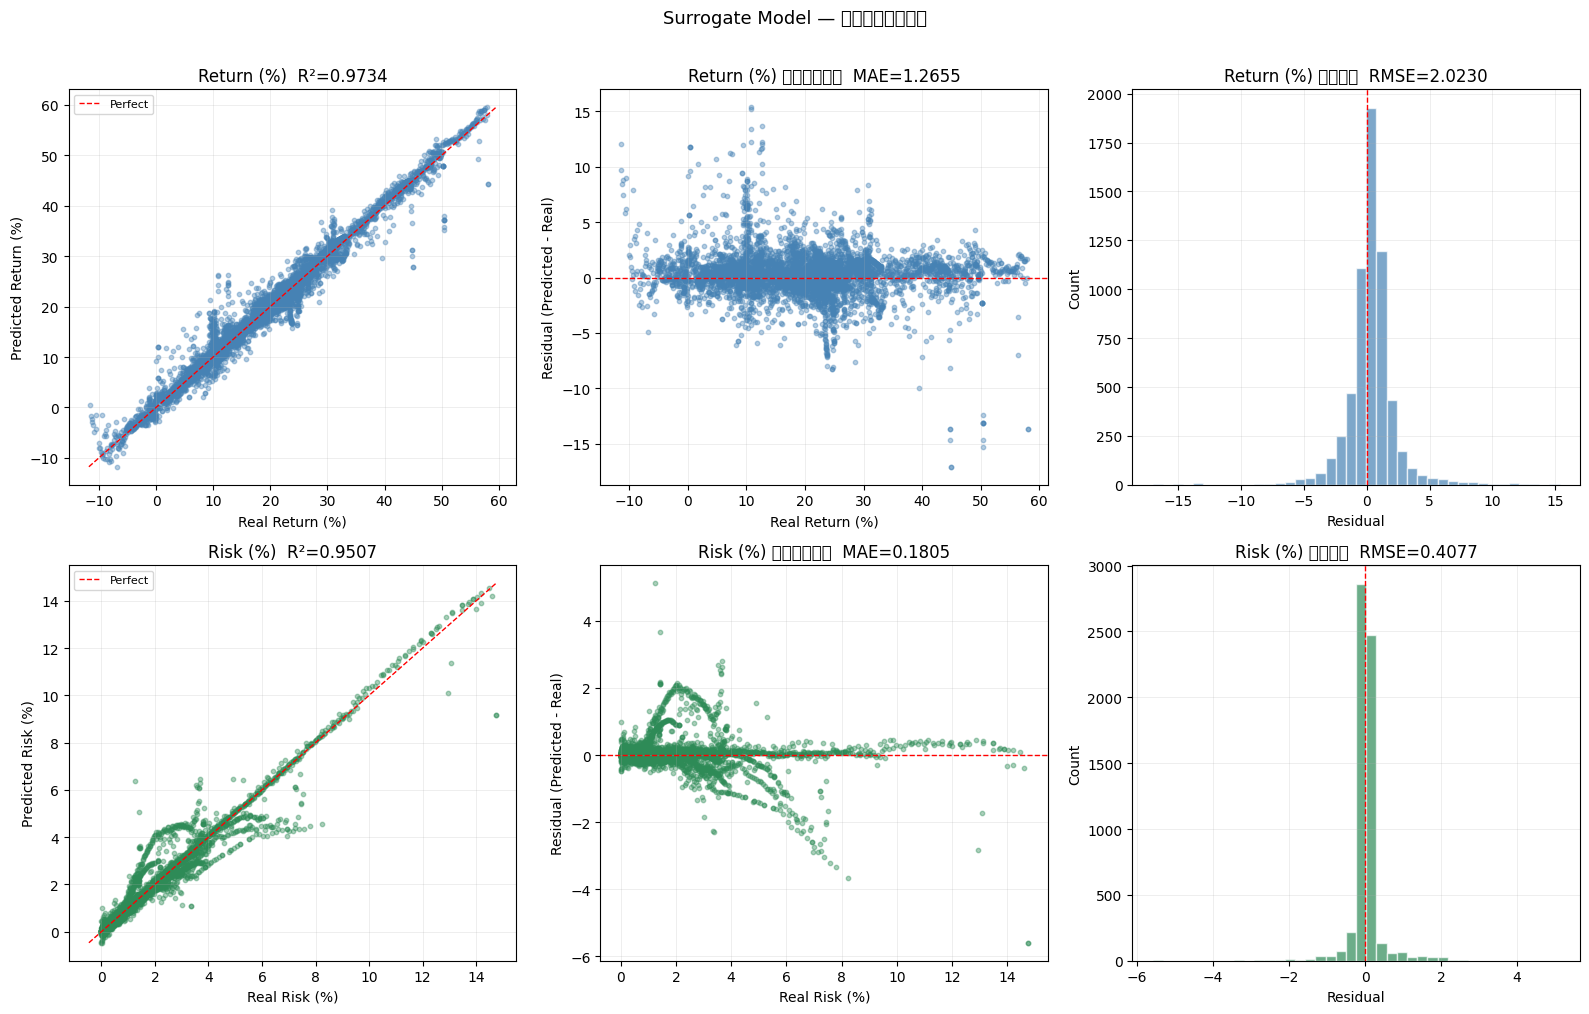

In [30]:
import numpy as np
import pandas as pd
import torch

# ==========================================
# 5. 学習結果の確認（複数の評価指標）
# ==========================================
print("\n=== サロゲートモデルの予測精度チェック ===")

model.eval()
with torch.no_grad():
    predictions_scaled = model(X_tensor)

predictions = scaler_y.inverse_transform(predictions_scaled.numpy())
y_true      = y_data * 100          # % スケールに戻す
y_pred      = predictions * 100

# ==========================================
# 評価関数の定義
# ==========================================

def mae(true, pred):
    """平均絶対誤差 — 誤差の平均的な大きさ（外れ値に頑健）"""
    return np.mean(np.abs(true - pred))

def mse(true, pred):
    """平均二乗誤差 — 大きな誤差を強く罰則化"""
    return np.mean((true - pred) ** 2)

def rmse(true, pred):
    """二乗平均平方根誤差 — MSEを元の単位に戻したもの"""
    return np.sqrt(mse(true, pred))

def mape(true, pred, eps=1e-8):
    """平均絶対パーセント誤差 — 相対的な誤差率(%)"""
    return np.mean(np.abs((true - pred) / (np.abs(true) + eps))) * 100

def r2(true, pred):
    """決定係数 R² — 1.0が完全予測、0以下はモデルが意味をなさない"""
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - np.mean(true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-8)

def adjusted_r2(true, pred, n_features):
    """調整済み R² — 特徴量数を考慮したR²（過学習に敏感）"""
    n = len(true)
    r2_val = r2(true, pred)
    return 1 - (1 - r2_val) * (n - 1) / (n - n_features - 1)

def max_error(true, pred):
    """最大絶対誤差 — 最悪ケースの誤差"""
    return np.max(np.abs(true - pred))

def median_ae(true, pred):
    """中央値絶対誤差 — 外れ値の影響を受けない頑健な指標"""
    return np.median(np.abs(true - pred))

def explained_variance(true, pred):
    """説明分散スコア — 予測が分散をどれだけ説明できているか（1.0が最良）"""
    var_res = np.var(true - pred)
    var_tot = np.var(true)
    return 1 - var_res / (var_tot + 1e-8)

def relative_rmse(true, pred):
    """相対RMSE — RMSEを正解の範囲で正規化（スケール不変の比較に便利）"""
    return rmse(true, pred) / (np.max(true) - np.min(true) + 1e-8)

def pearson_r(true, pred):
    """ピアソン相関係数 — 予測と正解の線形相関（1.0が完全一致）"""
    return np.corrcoef(true, pred)[0, 1]

def within_tolerance(true, pred, tol):
    """許容誤差内の割合 — 誤差がtol(%)以内に収まるサンプルの比率"""
    return np.mean(np.abs(true - pred) <= tol) * 100

# ==========================================
# 各ターゲット（Return / Risk）に対して評価
# ==========================================
N_FEATURES = X_tensor.shape[1]   # 入力の特徴量数（調整済みR²に使用）
TARGETS = {
    "Return (%)": (y_true[:, 0], y_pred[:, 0]),
    "Risk (%)":   (y_true[:, 1], y_pred[:, 1]),
}

rows = []
for name, (yt, yp) in TARGETS.items():
    rows.append({
        "ターゲット":          name,
        "MAE":                 round(mae(yt, yp),                 4),
        "RMSE":                round(rmse(yt, yp),                4),
        "MAPE (%)":            round(mape(yt, yp),                4),
        "R²":                  round(r2(yt, yp),                  4),
        "調整済みR²":          round(adjusted_r2(yt, yp, N_FEATURES), 4),
        "最大誤差":            round(max_error(yt, yp),           4),
        "中央値絶対誤差":      round(median_ae(yt, yp),           4),
        "説明分散":            round(explained_variance(yt, yp),  4),
        "相対RMSE":            round(relative_rmse(yt, yp),       4),
        "ピアソンr":           round(pearson_r(yt, yp),           4),
        "±0.5%以内の割合(%)":  round(within_tolerance(yt, yp, 0.5), 1),
        "±1.0%以内の割合(%)":  round(within_tolerance(yt, yp, 1.0), 1),
    })

metrics_df = pd.DataFrame(rows).set_index("ターゲット")

print("\n▼ 評価指標一覧:")
print(metrics_df.T.to_string())

# ==========================================
# 最初の5件の比較（答え合わせ）
# ==========================================
comparison_df = pd.DataFrame({
    "本物のReturn (%)": y_true[:5, 0],
    "AI予測Return (%)": y_pred[:5, 0],
    "誤差Return (%)":   y_pred[:5, 0] - y_true[:5, 0],
    "本物のRisk (%)":   y_true[:5, 1],
    "AI予測Risk (%)":   y_pred[:5, 1],
    "誤差Risk (%)":     y_pred[:5, 1] - y_true[:5, 1],
})
print("\n▼ 最初の5件の比較（誤差付き）:")
print(comparison_df.round(4).to_string(index=False))

# ==========================================
# グラフ可視化
# ==========================================
try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig)

    def plot_scatter(ax, yt, yp, label, color):
        ax.scatter(yt, yp, alpha=0.4, s=10, color=color)
        lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
        ax.plot(lim, lim, 'r--', lw=1, label='Perfect')
        ax.set_title(f"{label}  R²={r2(yt, yp):.4f}")
        ax.set_xlabel(f"Real {label}")
        ax.set_ylabel(f"Predicted {label}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    def plot_residual(ax, yt, yp, label, color):
        residuals = yp - yt
        ax.scatter(yt, residuals, alpha=0.4, s=10, color=color)
        ax.axhline(0, color='r', lw=1, linestyle='--')
        ax.set_title(f"{label} 残差プロット  MAE={mae(yt, yp):.4f}")
        ax.set_xlabel(f"Real {label}")
        ax.set_ylabel("Residual (Predicted - Real)")
        ax.grid(True, alpha=0.3)

    def plot_hist(ax, yt, yp, label, color):
        residuals = yp - yt
        ax.hist(residuals, bins=40, color=color, alpha=0.7, edgecolor='white')
        ax.axvline(0, color='r', lw=1, linestyle='--')
        ax.set_title(f"{label} 誤差分布  RMSE={rmse(yt, yp):.4f}")
        ax.set_xlabel("Residual")
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.3)

    yt_r, yp_r = y_true[:, 0], y_pred[:, 0]
    yt_k, yp_k = y_true[:, 1], y_pred[:, 1]

    plot_scatter (fig.add_subplot(gs[0, 0]), yt_r, yp_r, "Return (%)", "steelblue")
    plot_residual(fig.add_subplot(gs[0, 1]), yt_r, yp_r, "Return (%)", "steelblue")
    plot_hist    (fig.add_subplot(gs[0, 2]), yt_r, yp_r, "Return (%)", "steelblue")
    plot_scatter (fig.add_subplot(gs[1, 0]), yt_k, yp_k, "Risk (%)",   "seagreen")
    plot_residual(fig.add_subplot(gs[1, 1]), yt_k, yp_k, "Risk (%)",   "seagreen")
    plot_hist    (fig.add_subplot(gs[1, 2]), yt_k, yp_k, "Risk (%)",   "seagreen")

    plt.suptitle("Surrogate Model — 予測精度の可視化", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("\n※ matplotlib がないためグラフはスキップしました。")